In [2]:
import numpy as np

import numpy as np 
import matplotlib.pyplot as plt

from time import time

import sys 
sys.path.append('..')

import PyESRSTM

hartree = PyESRSTM.Hartree

In [3]:
Right = PyESRSTM.Electrode(0,   0, 0.,     5e-3,       1e-1,         4.5,  Nint=1e4, Cutoff=1000)
Left = PyESRSTM.Electrode(-25, 5, 0.5, 1.25e-3, 1e-1, 4.5, Nint=1e4, Cutoff=1000)

dot = PyESRSTM.QD(-30, 100, np.array([0.5]), np.array([[0.20804273,  0.00000000,  0.57159271]]), np.array([[2.0, 2.0, 2.0]]))

Hermiticity check passed!


In [4]:
l_idx= np.array([2,3])
dosR = Right.dos(0)
F1s = np.empty(10, dtype=complex)

for idx, Vdc in enumerate(np.linspace(-40, -20, 10)):
    fermiR = lambda x: Right.FermiFunctionArray((x-Vdc/hartree)/Right.Temperature)
    fermiRh = lambda x: 1-fermiR(x)

    def F1RR(D, s):
        # rho_R**2 sum_l fermiR(D_lj)*fermiR(D_lj -/+ D_ij)
        ##print(1)
        return dosR**2*np.sum(fermiR(D)*fermiRh(D - s*dot.Delta[0,1]))

    F1s[idx] = F1RR(dot.Delta[l_idx,1], 1) + F1RR(dot.Delta[0,l_idx], 1)

/home/matyas/miniconda3/envs/PyESRSTM-cot/lib/python3.12/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/matyas/miniconda3/envs/PyESRSTM-cot/lib/python3.12/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


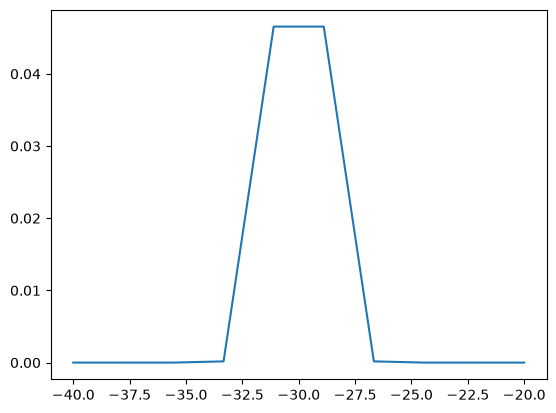

In [5]:
plt.plot(np.linspace(-40, -20, 10), F1s, label='F1p real')

0.5


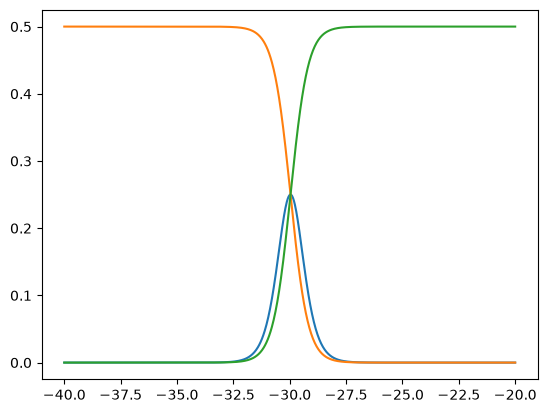

In [6]:

Vdcs = np.linspace(-40, -20, 1000)

FR = 1/2*Right.FermiFunctionfloat((dot.Delta[2,1]-0)/Right.Temperature)
FL = Left.FermiFunctionArray((dot.Delta[2,1]-Vdcs/hartree)/Left.Temperature)
print(FR)
plt.plot(Vdcs, FL*(1-FL))

plt.plot(Vdcs, FR*(1-FL))
plt.plot(Vdcs, FL*(1-FR))


In [7]:
Vdcs = np.linspace(-100, 100, 100)
F1ps = np.empty((len(Vdcs),4), dtype=complex)
F1ms = np.empty((len(Vdcs),4), dtype=complex)
F2s = np.empty((len(Vdcs),4), dtype=complex)

for i, Vdc in enumerate(Vdcs):
    Left = PyESRSTM.Electrode(Vdc, 5, 0.5, 1.25e-3, 1e-1, 4.5, Nint=1e4, Cutoff=100)
    
    F1ps[i], F1ms[i], F2s[i] = PyESRSTM.Golden.cottuneling.integrals.all_integrals(Left, Right, 17.1, dot.Delta, Left.gammaC, n_int_four=int(1e3), n_int_ener=1000, n_four = 0)
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


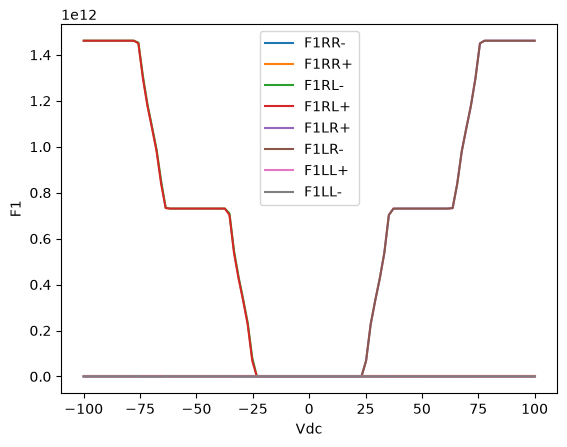

In [8]:
plt.plot(Vdcs, F1ms.real[:,0], label='F1RR-')
plt.plot(Vdcs, F1ps.real[:,0], label='F1RR+')

plt.plot(Vdcs, F1ms.real[:,1], label='F1RL-')
plt.plot(Vdcs, F1ps.real[:,1], label='F1RL+')

plt.plot(Vdcs, F1ps.real[:,2], label='F1LR+')
plt.plot(Vdcs, F1ms.real[:,2], label='F1LR-')

plt.plot(Vdcs, F1ps.real[:,3], label='F1LL+')
plt.plot(Vdcs, F1ms.real[:,3], label='F1LL-')


plt.legend()
plt.xlabel('Vdc')
plt.ylabel('F1')
plt.show()

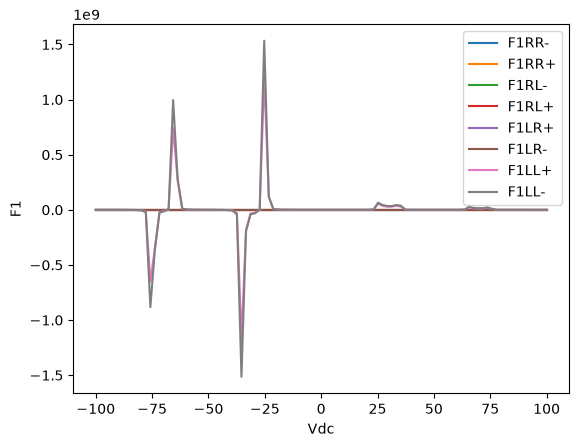

In [9]:
plt.plot(Vdcs, F1ms.imag[:,0], label='F1RR-')
plt.plot(Vdcs, F1ps.imag[:,0], label='F1RR+')

plt.plot(Vdcs, F1ms.imag[:,1], label='F1RL-')
plt.plot(Vdcs, F1ps.imag[:,1], label='F1RL+')

plt.plot(Vdcs, F1ps.imag[:,2], label='F1LR+')
plt.plot(Vdcs, F1ms.imag[:,2], label='F1LR-')

plt.plot(Vdcs, F1ps.imag[:,3], label='F1LL+')
plt.plot(Vdcs, F1ms.imag[:,3], label='F1LL-')


plt.legend()
plt.xlabel('Vdc')
plt.ylabel('F1')
plt.show()

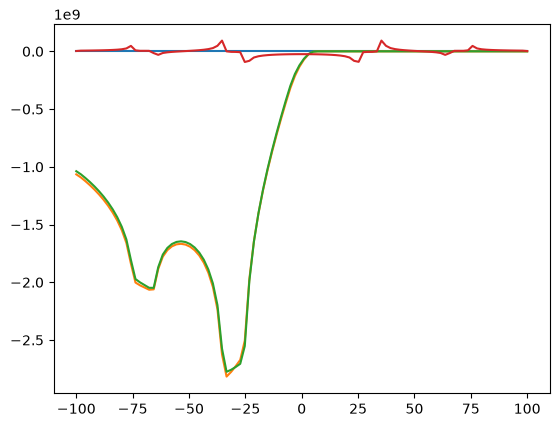

In [10]:
plt.plot(Vdcs, F2s.real[:,0], label='F2RR')
plt.plot(Vdcs, F2s.real[:,1], label='F2RL')
plt.plot(Vdcs, F2s.real[:,2], label='F2LR')
plt.plot(Vdcs, F2s.real[:,3], label='F2LL')

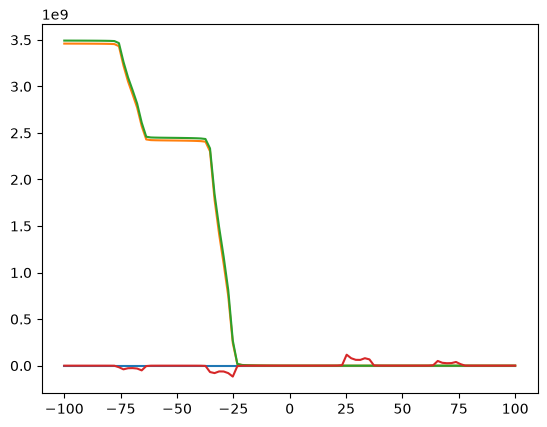

In [11]:
plt.plot(Vdcs, F2s.imag[:,0], label='F2RR')
plt.plot(Vdcs, F2s.imag[:,1], label='F2RL')
plt.plot(Vdcs, F2s.imag[:,2], label='F2LR')
plt.plot(Vdcs, F2s.imag[:,3], label='F2LL')

In [12]:
fermiR = lambda x,D: Right.FermiFunctionArray((D-x)/Right.Temperature)
fermiL = lambda x, D: Left.FermiFunctionArray((D-x)/Left.Temperature)
fermiRh = lambda x,D: 1-fermiR(x,D)
fermiLh = lambda x,D: 1-fermiL(x,D)

In [13]:
fRfR = lambda x: fermiR(0,-30)*fermiRh(x,-30) + fermiR(x,-70)*fermiRh(x,-70) + fermiR(x,-100)*fermiRh(x,-100) + fermiR(x,-130)*fermiRh(x,-130)

In [14]:
plt.plot(Vdcs, fermiR(Vdcs/hartree), label='fermiR')
plt.plot(Vdcs, fermiL(Vdcs/hartree), label='fermiL')
plt.plot(Vdcs, fermiRh(Vdcs/hartree), label='fermiRh')
plt.plot(Vdcs, fermiLh(Vdcs/hartree), label='fermiLh')

plt.legend()
plt.xlabel('Vdc')
plt.ylabel('Fermi Function')
plt.show()

TypeError: <lambda>() missing 1 required positional argument: 'D'